# Phase 4 — Voter Turnout Prediction Model

## Eastern Cape Municipal Electoral Dynamics

Phase 4 builds and evaluates models for **municipality-level voter turnout**.

### Prediction question

> How accurately can the next local-government-election turnout of an Eastern Cape municipality be estimated from information available before that election?

### Evaluation design

This notebook uses a **historical backtest**:

- **Training:** 2011 and 2016 municipality-election observations
- **Holdout test:** 2021
- **Unit:** municipality × election
- **Primary metric:** Mean Absolute Error (MAE), in percentage points
- **Secondary metrics:** RMSE and R²

The most important benchmark is a simple persistence baseline:

> **Next turnout = previous election turnout**

A more complex model is only useful if it improves meaningfully on simple historical baselines.

### Leakage rule

Same-election outcomes such as ENP, victory margin, party shares and top-party share are **not predictors** because they are not known before the election.

The primary backtest also avoids using interpolated demographic values as core predictors because the interpolation uses the 2022 Census endpoint. Those variables are valuable for Phase 3 descriptive analysis and later scenario work, but using them in a strict pre-2021 historical forecast would introduce future information.

Therefore the primary Phase 4 model is intentionally conservative and leakage-safe.


In [2]:
%pip install scikit-learn


  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 6.5 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 7.7 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 7.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 7.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.2 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 7.2 MB/s  0:00:01
Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl (36.6 MB)

   ---------------------------------------- 0/6 [threadpoolctl]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]


In [4]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("Run this notebook from inside the DIRISA project.")

PROJECT_ROOT = find_project_root()
PHASE3_DIR = PROJECT_ROOT / "data" / "processed" / "panels" / "phase3"
PHASE4_DIR = PROJECT_ROOT / "data" / "processed" / "models" / "phase4"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "phase4"

PHASE4_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = PHASE3_DIR / "turnout_model_ready_2011_2021.csv"

if not MODEL_FILE.exists():
    raise FileNotFoundError(
        f"Missing {MODEL_FILE}. Run Phase 3 successfully before Phase 4."
    )

df = pd.read_csv(MODEL_FILE)

print("Project root:", PROJECT_ROOT)
print("Model dataset:", MODEL_FILE.relative_to(PROJECT_ROOT))
print("Shape:", df.shape)
display(df.head())


Project root: C:\Users\Monwabisi05\IdeaProjects\Dirisa_TeamQualification
Model dataset: data\processed\panels\phase3\turnout_model_ready_2011_2021.csv
Shape: (99, 19)


,MuniCode,Year,Turnout_%,PreviousRegisteredVoters,PreviousTurnout_%,PreviousENP,PreviousMargin_pts,PreviousTopShare_%,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,DemographicStatus
0,BUF,2011,56.261464,358460.0,52.260782,1.477063,69.401808,81.334215,781853.0,26.5,6.1,27.0,5.1,27.1,13.2,71.9,69.1,81.1,Observed
1,EC101,2011,62.354111,34211.0,53.669872,2.112625,33.518313,62.280799,79292.0,30.2,6.8,26.0,9.3,18.4,7.6,95.3,96.9,92.1,Observed
2,EC102,2011,59.039597,17453.0,53.326076,1.657324,52.410167,74.441280,36002.0,29.2,7.0,27.0,10.5,19.0,6.1,95.9,91.4,86.9,Observed
3,EC104,2011,55.798199,43059.0,52.397873,1.482204,66.942707,80.908232,80390.0,24.4,6.2,26.0,6.3,23.0,11.7,85.4,85.2,89.5,Observed
4,EC105,2011,67.149268,29895.0,62.759659,1.557806,57.749744,77.583697,61176.0,25.2,9.9,25.0,9.7,20.4,9.6,83.6,86.0,86.3,Observed


## 1. Validate the modelling dataset

Phase 3 should provide exactly **99 observations**:

- 33 for 2011
- 33 for 2016
- 33 for 2021

The target is `Turnout_%`.

The primary predictors are lagged election variables, meaning information from the **previous** local election.


In [5]:
PRIMARY_FEATURES = [
    "PreviousTurnout_%",
    "PreviousENP",
    "PreviousMargin_pts",
    "PreviousRegisteredVoters",
]

TARGET = "Turnout_%"

required = ["MuniCode", "Year", TARGET] + PRIMARY_FEATURES
missing_cols = [x for x in required if x not in df.columns]
assert not missing_cols, f"Missing required columns: {missing_cols}"

assert len(df) == 99
assert df["MuniCode"].nunique() == 33
assert df.groupby("Year").size().to_dict() == {2011: 33, 2016: 33, 2021: 33}
assert df[required].notna().all().all()
assert df[TARGET].between(0, 100).all()

print("PASS: modelling dataset validated.")
print("\nTarget:", TARGET)
print("Primary features:", PRIMARY_FEATURES)


PASS: modelling dataset validated.

Target: Turnout_%
Primary features: ['PreviousTurnout_%', 'PreviousENP', 'PreviousMargin_pts', 'PreviousRegisteredVoters']


## 2. Temporal train/test split

We do **not** randomly split municipality-election rows.

A random split could allow later-election patterns to influence a model evaluated on earlier observations. Instead:

- train on 2011 + 2016;
- test once on 2021.

This better represents the real task of forecasting a future election from past elections.


In [6]:
train = df[df["Year"].isin([2011, 2016])].copy()
test = df[df["Year"] == 2021].copy()

X_train = train[PRIMARY_FEATURES]
y_train = train[TARGET]

X_test = test[PRIMARY_FEATURES]
y_test = test[TARGET]

print("Training observations:", len(train))
print("Test observations:", len(test))
print("Training years:", sorted(train["Year"].unique()))
print("Holdout year:", test["Year"].unique().tolist())


Training observations: 66
Test observations: 33
Training years: [np.int64(2011), np.int64(2016)]
Holdout year: [2021]


## 3. Baseline models

Before machine learning, establish simple benchmarks.

### Baseline A — Previous turnout
Assume the municipality's turnout remains the same as at the previous election.

### Baseline B — Average historical turnout change
Calculate the average turnout change observed in the training elections, then add that change to each municipality's previous turnout.

These baselines answer an important question:

> Does machine learning add predictive value beyond simple historical persistence?


In [7]:
baseline_previous = test["PreviousTurnout_%"].to_numpy()

train_change = train[TARGET] - train["PreviousTurnout_%"]
average_train_change = train_change.mean()

baseline_avg_change = (
    test["PreviousTurnout_%"] + average_train_change
).clip(0, 100).to_numpy()

print(f"Average turnout change learned from training: {average_train_change:.2f} percentage points")


Average turnout change learned from training: -0.48 percentage points


## 4. Candidate models

Given the small dataset, Phase 4 deliberately compares a small number of understandable models:

1. **Linear Regression** — simple interpretable benchmark.
2. **Ridge Regression** — regularised linear model, useful when predictors are correlated.
3. **Random Forest** — nonlinear comparison model.

The Random Forest is included as a comparison, not assumed to be superior. With only 66 training observations, complex models can easily overfit.


In [8]:
models = {
    "Linear Regression": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    "Ridge Regression": make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42
    ),
}

predictions = {
    "Previous Turnout Baseline": baseline_previous,
    "Average Change Baseline": baseline_avg_change,
}

fitted_models = {}

for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    pred = np.clip(fitted.predict(X_test), 0, 100)
    predictions[name] = pred
    fitted_models[name] = fitted

print("Models fitted successfully.")


Models fitted successfully.


## 5. Evaluate the 2021 historical backtest

In [9]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE_pts": mean_absolute_error(y_true, y_pred),
        "RMSE_pts": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

rows = []
for name, pred in predictions.items():
    m = regression_metrics(y_test, pred)
    rows.append({"Model": name, **m})

results = (
    pd.DataFrame(rows)
    .sort_values("MAE_pts")
    .reset_index(drop=True)
)

display(results.round(3))


,Model,MAE_pts,RMSE_pts,R2
0,Average Change Baseline,7.725,8.210,-3.436
1,Previous Turnout Baseline,8.204,8.662,-3.938
2,Random Forest,8.795,9.487,-4.923
3,Ridge Regression,9.428,9.975,-5.549
4,Linear Regression,9.527,10.080,-5.687


### How to interpret this table

Lower **MAE** and **RMSE** indicate smaller prediction errors.

R² is reported as a secondary descriptive metric. On a small, single-election holdout, it can be unstable and should not be interpreted by itself.

The model comparison should be reported exactly as observed. If a simple baseline performs as well as or better than a machine-learning model, that is an important result rather than a failure.


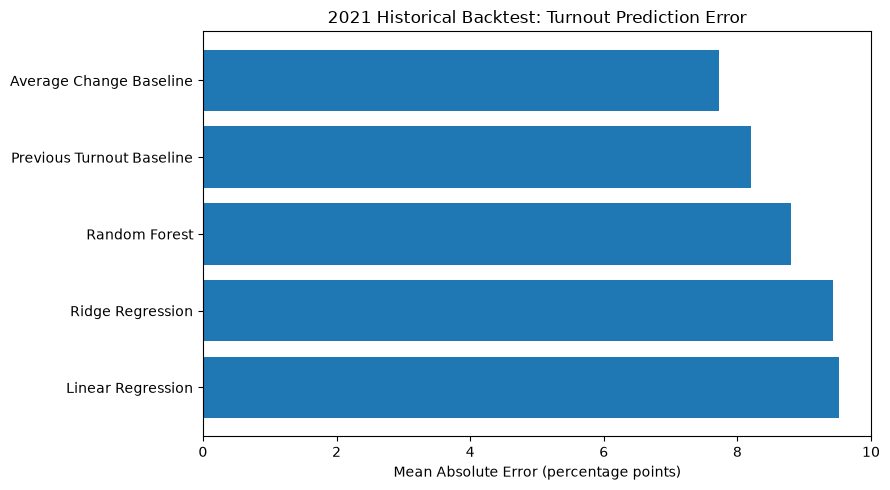

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_results = results.sort_values("MAE_pts", ascending=False)
ax.barh(plot_results["Model"], plot_results["MAE_pts"])
ax.set_title("2021 Historical Backtest: Turnout Prediction Error")
ax.set_xlabel("Mean Absolute Error (percentage points)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "turnout_model_mae_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Municipality-level holdout predictions

In [11]:
prediction_table = test[[
    "MuniCode", "Year", TARGET, "PreviousTurnout_%"
]].copy()

for name, pred in predictions.items():
    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    prediction_table[f"Pred_{safe_name}"] = pred
    prediction_table[f"AbsError_{safe_name}"] = np.abs(
        prediction_table[TARGET] - pred
    )

display(prediction_table.head())


,MuniCode,Year,Turnout_%,PreviousTurnout_%,Pred_previous_turnout_baseline,AbsError_previous_turnout_baseline,Pred_average_change_baseline,AbsError_average_change_baseline,Pred_linear_regression,AbsError_linear_regression,Pred_ridge_regression,AbsError_ridge_regression,Pred_random_forest,AbsError_random_forest
66,BUF,2021,45.225666,55.749516,55.749516,10.523850,55.270917,10.045251,59.625633,14.399967,58.707913,13.482247,57.732638,12.506972
67,EC101,2021,46.864430,61.310441,61.310441,14.446011,60.831842,13.967412,61.817817,14.953386,62.159524,15.295094,62.664191,15.799761
68,EC102,2021,52.767672,59.830176,59.830176,7.062504,59.351577,6.583905,60.680876,7.913204,60.818325,8.050652,61.089981,8.322308
69,EC104,2021,42.925522,52.586318,52.586318,9.660796,52.107719,9.182197,57.156828,14.231306,57.336462,14.410940,58.279838,15.354316
70,EC105,2021,55.534472,65.232912,65.232912,9.698441,64.754314,9.219842,64.199825,8.665353,63.188859,7.654388,63.721086,8.186614


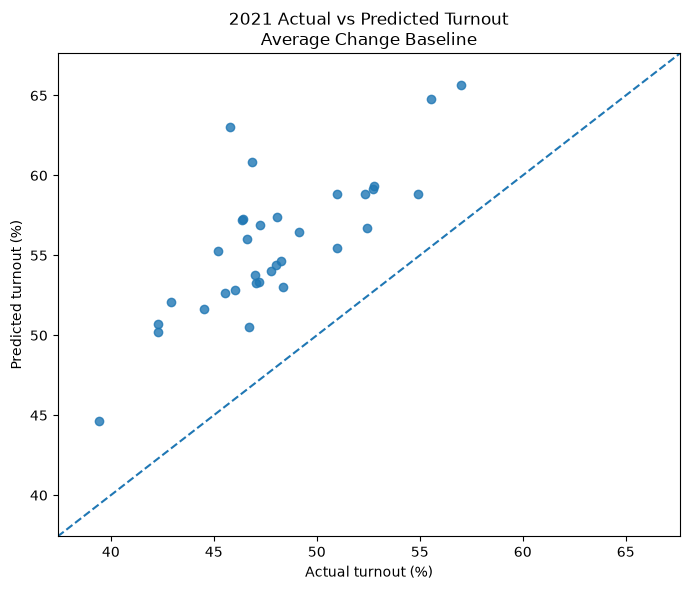

Lowest holdout MAE in this comparison: Average Change Baseline


In [12]:
best_model_name = results.iloc[0]["Model"]
best_pred = predictions[best_model_name]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_pred, alpha=0.8)

lo = min(y_test.min(), best_pred.min()) - 2
hi = max(y_test.max(), best_pred.max()) + 2
ax.plot([lo, hi], [lo, hi], linestyle="--")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_title(f"2021 Actual vs Predicted Turnout\n{best_model_name}")
ax.set_xlabel("Actual turnout (%)")
ax.set_ylabel("Predicted turnout (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "turnout_actual_vs_predicted_2021.png", dpi=180, bbox_inches="tight")
plt.show()

print("Lowest holdout MAE in this comparison:", best_model_name)


## 7. Model interpretation

For linear/Ridge models, coefficients describe predictive relationships after standardisation.

For Random Forest, feature importance describes how much the fitted model used each feature for splitting.

Neither should be interpreted as a causal effect.


In [13]:
interpretation_rows = []

ridge = fitted_models["Ridge Regression"]
ridge_coefs = ridge[-1].coef_

for feature, value in zip(PRIMARY_FEATURES, ridge_coefs):
    interpretation_rows.append({
        "Model": "Ridge Regression",
        "Feature": feature,
        "ImportanceOrCoefficient": value
    })

rf = fitted_models["Random Forest"]
for feature, value in zip(PRIMARY_FEATURES, rf.feature_importances_):
    interpretation_rows.append({
        "Model": "Random Forest",
        "Feature": feature,
        "ImportanceOrCoefficient": value
    })

feature_summary = pd.DataFrame(interpretation_rows)
display(feature_summary)


,Model,Feature,ImportanceOrCoefficient
0,Ridge Regression,PreviousTurnout_%,1.866778
1,Ridge Regression,PreviousENP,0.975859
2,Ridge Regression,PreviousMargin_pts,-0.541110
3,Ridge Regression,PreviousRegisteredVoters,-0.257704
4,Random Forest,PreviousTurnout_%,0.367897
5,Random Forest,PreviousENP,0.114846
6,Random Forest,PreviousMargin_pts,0.168527
7,Random Forest,PreviousRegisteredVoters,0.348731


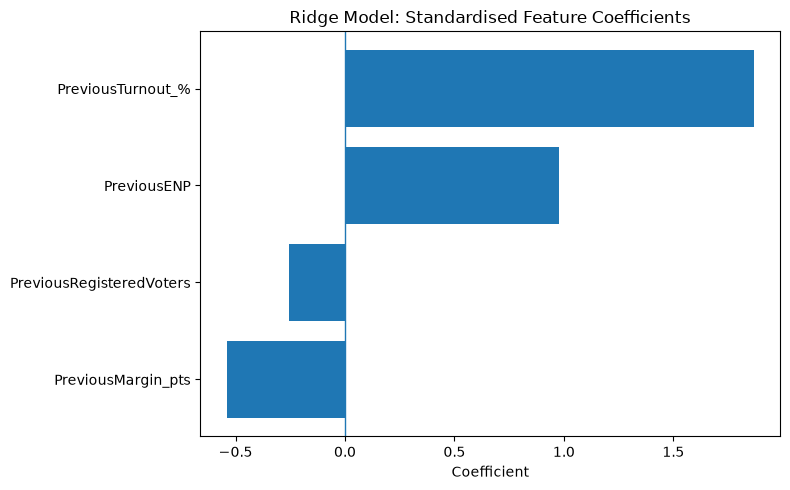

In [14]:
ridge_plot = (
    feature_summary[feature_summary["Model"] == "Ridge Regression"]
    .sort_values("ImportanceOrCoefficient")
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ridge_plot["Feature"], ridge_plot["ImportanceOrCoefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("Ridge Model: Standardised Feature Coefficients")
ax.set_xlabel("Coefficient")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ridge_feature_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Robustness check: expanding-window historical validation

The main evaluation is the 2021 holdout.

As an additional check, we can also test whether the same modelling approach works when predicting:

- **2016** from 2011 observations;
- **2021** from 2011 + 2016 observations.

This is not conventional large-sample cross-validation. It is a small, time-ordered robustness check designed for the limited number of local elections available.


In [15]:
validation_rows = []

for test_year, train_years in [
    (2016, [2011]),
    (2021, [2011, 2016]),
]:
    tr = df[df["Year"].isin(train_years)].copy()
    te = df[df["Year"] == test_year].copy()

    Xtr, ytr = tr[PRIMARY_FEATURES], tr[TARGET]
    Xte, yte = te[PRIMARY_FEATURES], te[TARGET]

    # Persistence baseline
    pred_base = te["PreviousTurnout_%"].to_numpy()
    validation_rows.append({
        "TestYear": test_year,
        "TrainingYears": ",".join(map(str, train_years)),
        "Model": "Previous Turnout Baseline",
        **regression_metrics(yte, pred_base)
    })

    for name, model in models.items():
        fitted = clone(model)
        fitted.fit(Xtr, ytr)
        pred = np.clip(fitted.predict(Xte), 0, 100)
        validation_rows.append({
            "TestYear": test_year,
            "TrainingYears": ",".join(map(str, train_years)),
            "Model": name,
            **regression_metrics(yte, pred)
        })

temporal_validation = pd.DataFrame(validation_rows)
display(
    temporal_validation.sort_values(["TestYear", "MAE_pts"]).round(3)
)


,TestYear,TrainingYears,Model,MAE_pts,RMSE_pts,R2
0,2016,2011,Previous Turnout Baseline,2.492,3.205,0.441
3,2016,2011,Random Forest,3.310,4.145,0.064
2,2016,2011,Ridge Regression,3.762,4.658,-0.181
1,2016,2011,Linear Regression,4.042,5.003,-0.363
4,2021,"2011,2016",Previous Turnout Baseline,8.204,8.662,-3.938
7,2021,"2011,2016",Random Forest,8.795,9.487,-4.923
6,2021,"2011,2016",Ridge Regression,9.428,9.975,-5.549
5,2021,"2011,2016",Linear Regression,9.527,10.080,-5.687


## 9. Why demographics are not in the primary historical forecast

Phase 2 aligned demographic characteristics to election years by interpolating between the **2011 and 2022 Census snapshots**.

That is appropriate for retrospective description, but a strict model pretending to stand before the 2021 election would not have known the 2022 Census endpoint.

Including those interpolated values in the primary 2021 backtest would therefore make the historical forecast less defensible.

For this reason:

- Phase 3 uses the aligned demographics for **EDA and association analysis**.
- Phase 4's primary backtest uses **lagged electoral information**.
- Later 2026 scenario work can use the latest/current demographic information transparently as current context.

This separation prevents the model from appearing more predictive simply because it received future information.


## 10. Save Phase 4 outputs

The fitted comparison is saved as tables rather than treating one algorithm as permanently selected. The model used later for 2026 turnout scenarios should be chosen from these historical validation results and then retrained using all appropriate information available through 2021.


In [16]:
results.to_csv(PHASE4_DIR / "turnout_model_comparison_2021.csv", index=False)
prediction_table.to_csv(PHASE4_DIR / "turnout_predictions_2021.csv", index=False)
feature_summary.to_csv(PHASE4_DIR / "turnout_feature_interpretation.csv", index=False)
temporal_validation.to_csv(PHASE4_DIR / "turnout_temporal_validation.csv", index=False)

methodology = pd.DataFrame([
    ["Target", "Municipality turnout percentage"],
    ["Primary holdout", "2021"],
    ["Primary training years", "2011, 2016"],
    ["Primary features", ", ".join(PRIMARY_FEATURES)],
    ["Primary metric", "MAE in percentage points"],
    ["Baseline", "Previous election turnout"],
    ["Same-election leakage excluded", "ENP, margin, party shares, top share"],
    ["Future demographic leakage excluded", "Interpolated 2016/2021 demographic features not used in primary forecast"],
], columns=["Item", "Value"])

methodology.to_csv(PHASE4_DIR / "phase4_methodology.csv", index=False)

print("Saved Phase 4 outputs to:", PHASE4_DIR.relative_to(PROJECT_ROOT))
print("Saved Phase 4 figures to:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("\nPhase 4 complete.")


Saved Phase 4 outputs to: data\processed\models\phase4
Saved Phase 4 figures to: reports\figures\phase4

Phase 4 complete.


## Phase 4 completion note

Phase 4 provides an honest historical test of municipality turnout prediction.

It does **not** yet produce a 2026 turnout number. The purpose of this phase is to establish which modelling approach, if any, generalises to an unseen election better than simple historical baselines.

### Relationship to the teammate's work

The teammate's Ridge model predicting **ANC vote-share swing** is related to the overall project, but its target is party support rather than turnout. That logic should be revisited in the dedicated **party-support model phase**.

### Next phase

**Phase 5 — Party Support Model**

Phase 5 will model party vote shares using historical party support and other leakage-safe predictors, with a 2021 backtest before any 2026 party-support scenarios are generated.
